# Study C Main Invariance Analysis

Raw/main generations compared with harmless invariance perturbations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve()
    while NOTEBOOK_UTILS_DIR.name != "notebooks" and NOTEBOOK_UTILS_DIR.parent != NOTEBOOK_UTILS_DIR:
        NOTEBOOK_UTILS_DIR = NOTEBOOK_UTILS_DIR.parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_arm_values,
    plot_secondary_coverage_heatmap,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    plot_secondary_per_model_heatmaps,
    secondary_metric_headline,
    secondary_missing_table,
    secondary_not_measurable_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
study = "study_c"
lanes = ['invariance']
flat_all = load_secondary_flat(metric_root)
coverage_all = load_secondary_coverage(metric_root)
df = flat_all[(flat_all["study"] == study) & (flat_all["lane"].isin(lanes))].copy()
coverage = coverage_all[(coverage_all["study"] == study) & (coverage_all["lane"].isin(lanes))].copy()
print("Runtime root:", runtime_root)
print("Rows:", len(df), "Coverage rows:", len(coverage))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Rows: 8 Coverage rows: 6


## Provenance and coverage

,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
34,invariance,deepseek-r1-lmstudio,study_c,missing_cache,NaN,NaN,NaN,NaN,NaN
49,invariance,gpt-oss-20b,study_c,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
39,invariance,piaget-8b-local,study_c,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
54,invariance,psyche-r1-local,study_c,missing_cache,NaN,NaN,NaN,NaN,NaN
59,invariance,psyllm-lmstudio,study_c,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
44,invariance,qwen3-lmstudio,study_c,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
0,invariance,deepseek-r1-lmstudio,study_c,missing_cache,NaN,NaN,NaN,NaN,NaN
1,invariance,psyche-r1-local,study_c,missing_cache,NaN,NaN,NaN,NaN,NaN


,lane,model,study,variant,metric,reason,n_pairs


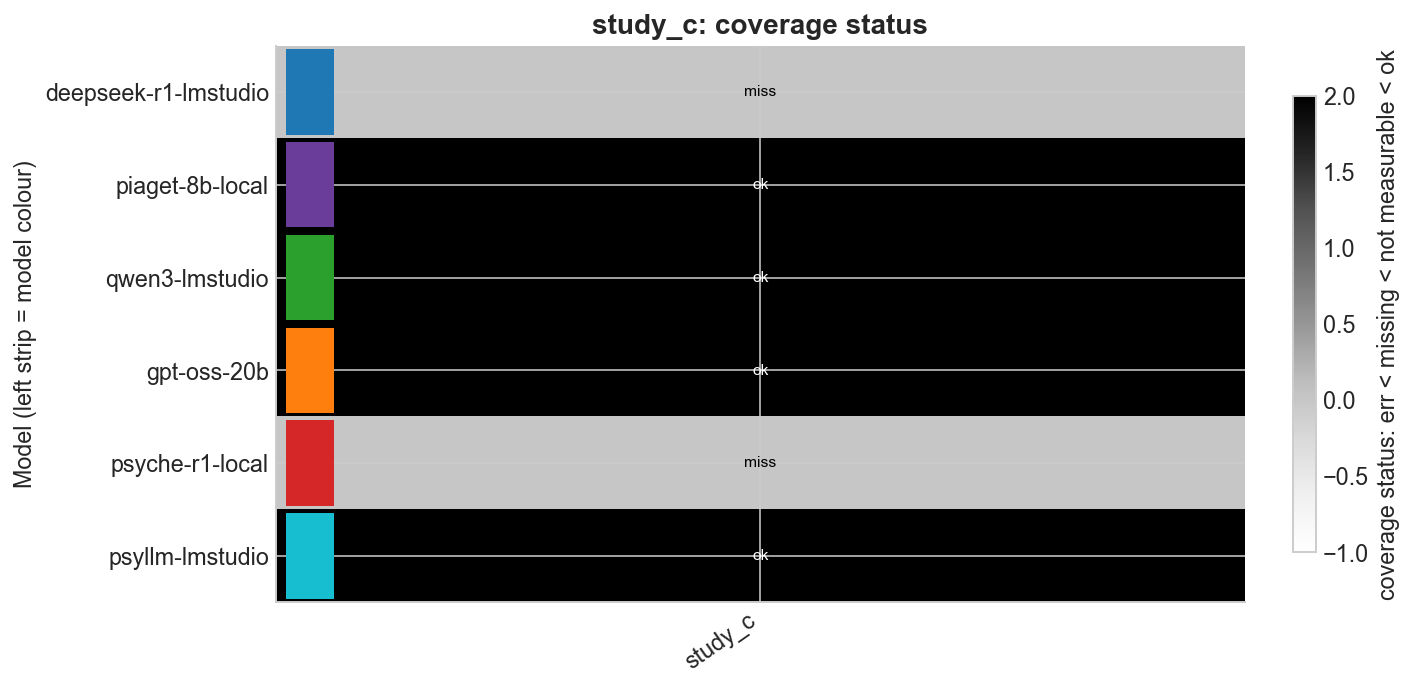

In [2]:
display(coverage.sort_values(["lane", "model", "study"]))
display(secondary_missing_table(coverage))
display(secondary_not_measurable_table(df))
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
plot_secondary_coverage_heatmap(coverage, ax=ax, title=f"{study}: coverage status")
plt.show()

## Metric headline table

In [3]:
headline = secondary_metric_headline(df)
display(headline.round(4))
audit = secondary_threshold_audit(df)
display(audit.round(4))

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,invariance,study_c,entity_recall_t10,4,0,0.0028,0.0708,0.6278,15.0,1
1,invariance,study_c,knowledge_conflict_rate,4,0,0.0018,0.0022,0.0035,15.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_c,invariance_variant,entity_recall_t10,2,0.8750,0.7500,-0.1250,-0.2500,0.0000,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_c,invariance_variant,entity_recall_t10,15,0.0333,0.6611,0.6278,0.4222,0.8278,CI excludes zero; reportable paired shift
2,invariance,psyllm-lmstudio,study_c,invariance_variant,entity_recall_t10,15,0.0000,0.0167,0.0167,0.0000,0.0500,CI overlaps zero; descriptive only
3,invariance,qwen3-lmstudio,study_c,invariance_variant,entity_recall_t10,15,0.5722,0.5611,-0.0111,-0.2111,0.1889,CI overlaps zero; descriptive only
4,invariance,gpt-oss-20b,study_c,invariance_variant,knowledge_conflict_rate,2,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
5,invariance,piaget-8b-local,study_c,invariance_variant,knowledge_conflict_rate,15,0.0000,0.0035,0.0035,0.0000,0.0105,CI overlaps zero; descriptive only
6,invariance,psyllm-lmstudio,study_c,invariance_variant,knowledge_conflict_rate,15,0.0267,0.0257,-0.0010,-0.0287,0.0284,CI overlaps zero; descriptive only
7,invariance,qwen3-lmstudio,study_c,invariance_variant,knowledge_conflict_rate,15,0.0035,0.0070,0.0035,-0.0070,0.0175,CI overlaps zero; descriptive only


## Paired-delta confidence intervals

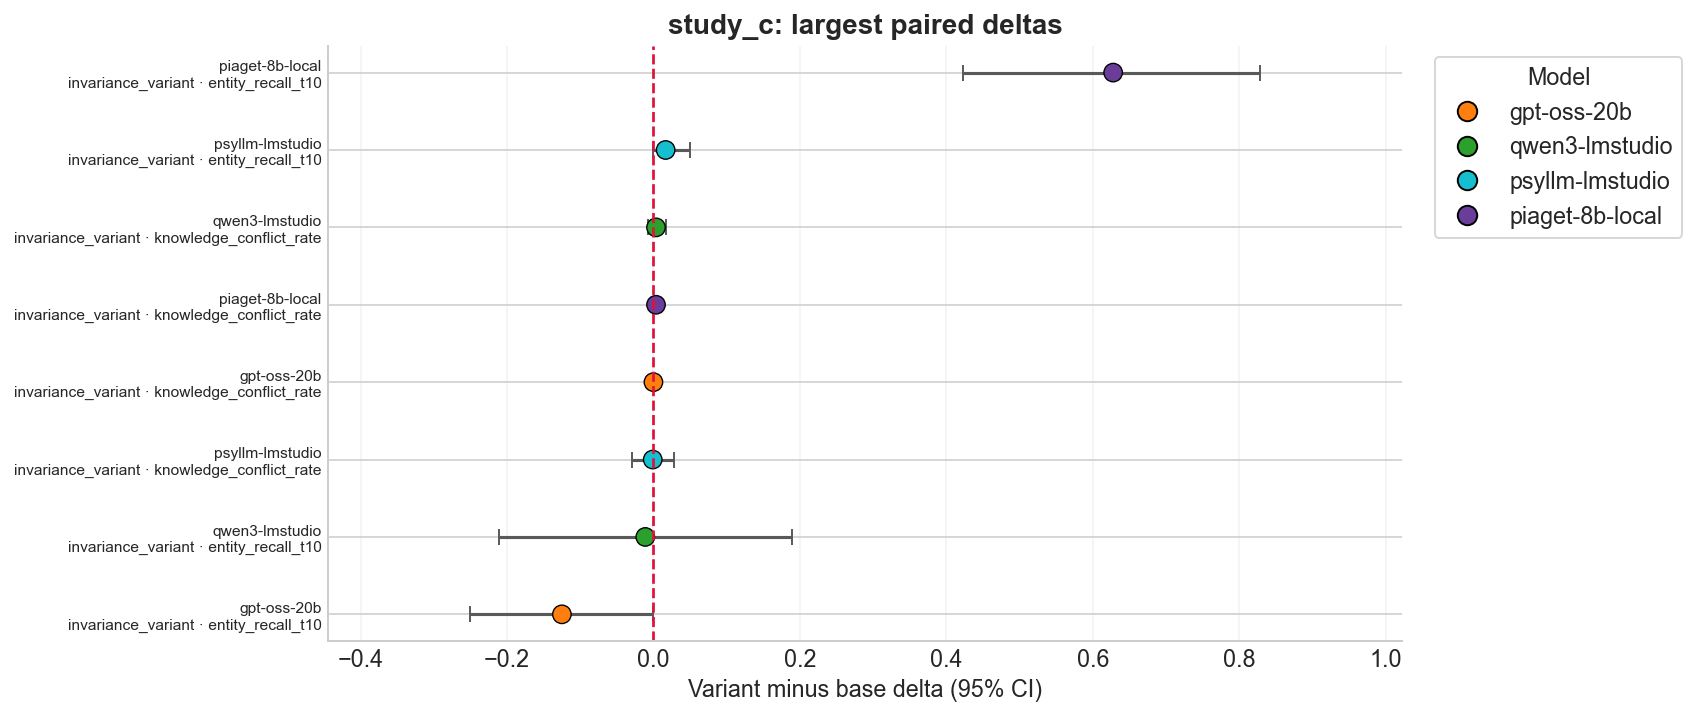

In [4]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(df), 8))), constrained_layout=True)
plot_secondary_delta_ci(df, ax=ax, title=f"{study}: largest paired deltas", max_rows=30)
plt.show()

## Base versus variant values

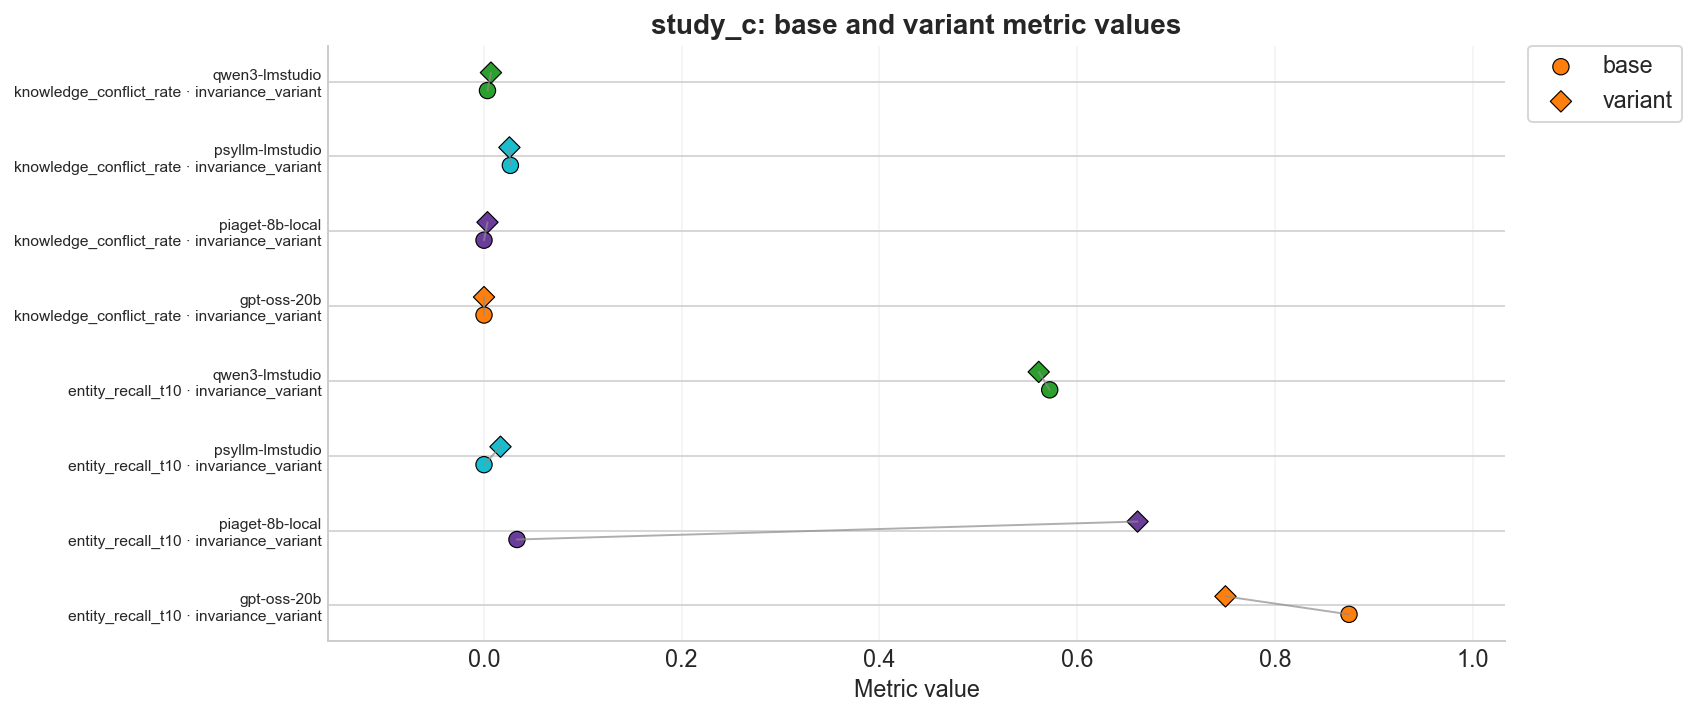

In [5]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * max(len(df), 8))), constrained_layout=True)
plot_secondary_arm_values(df, ax=ax, title=f"{study}: base and variant metric values", max_rows=28)
plt.show()

## Model sensitivity heatmap

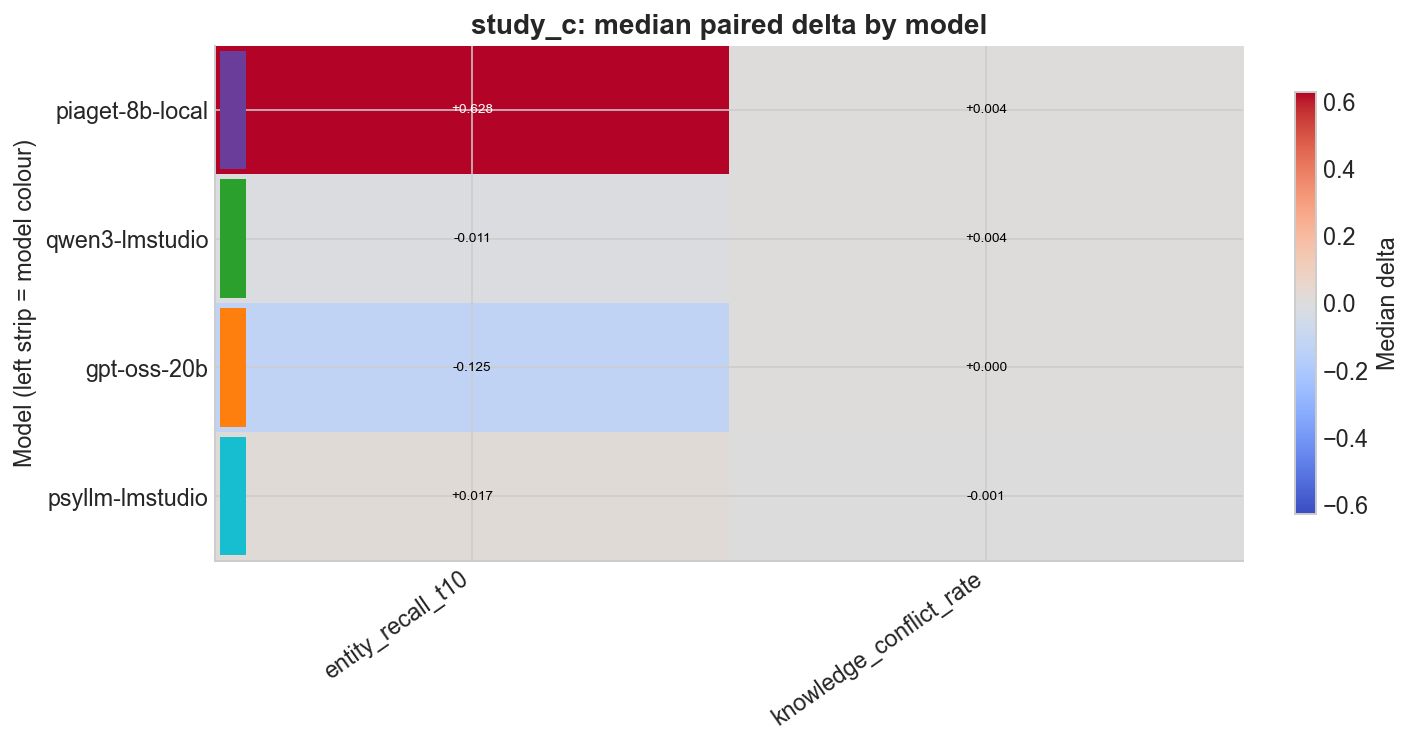

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
plot_secondary_model_heatmap(df, ax=ax, title=f"{study}: median paired delta by model")
plt.show()

## Model-separated metric heatmaps

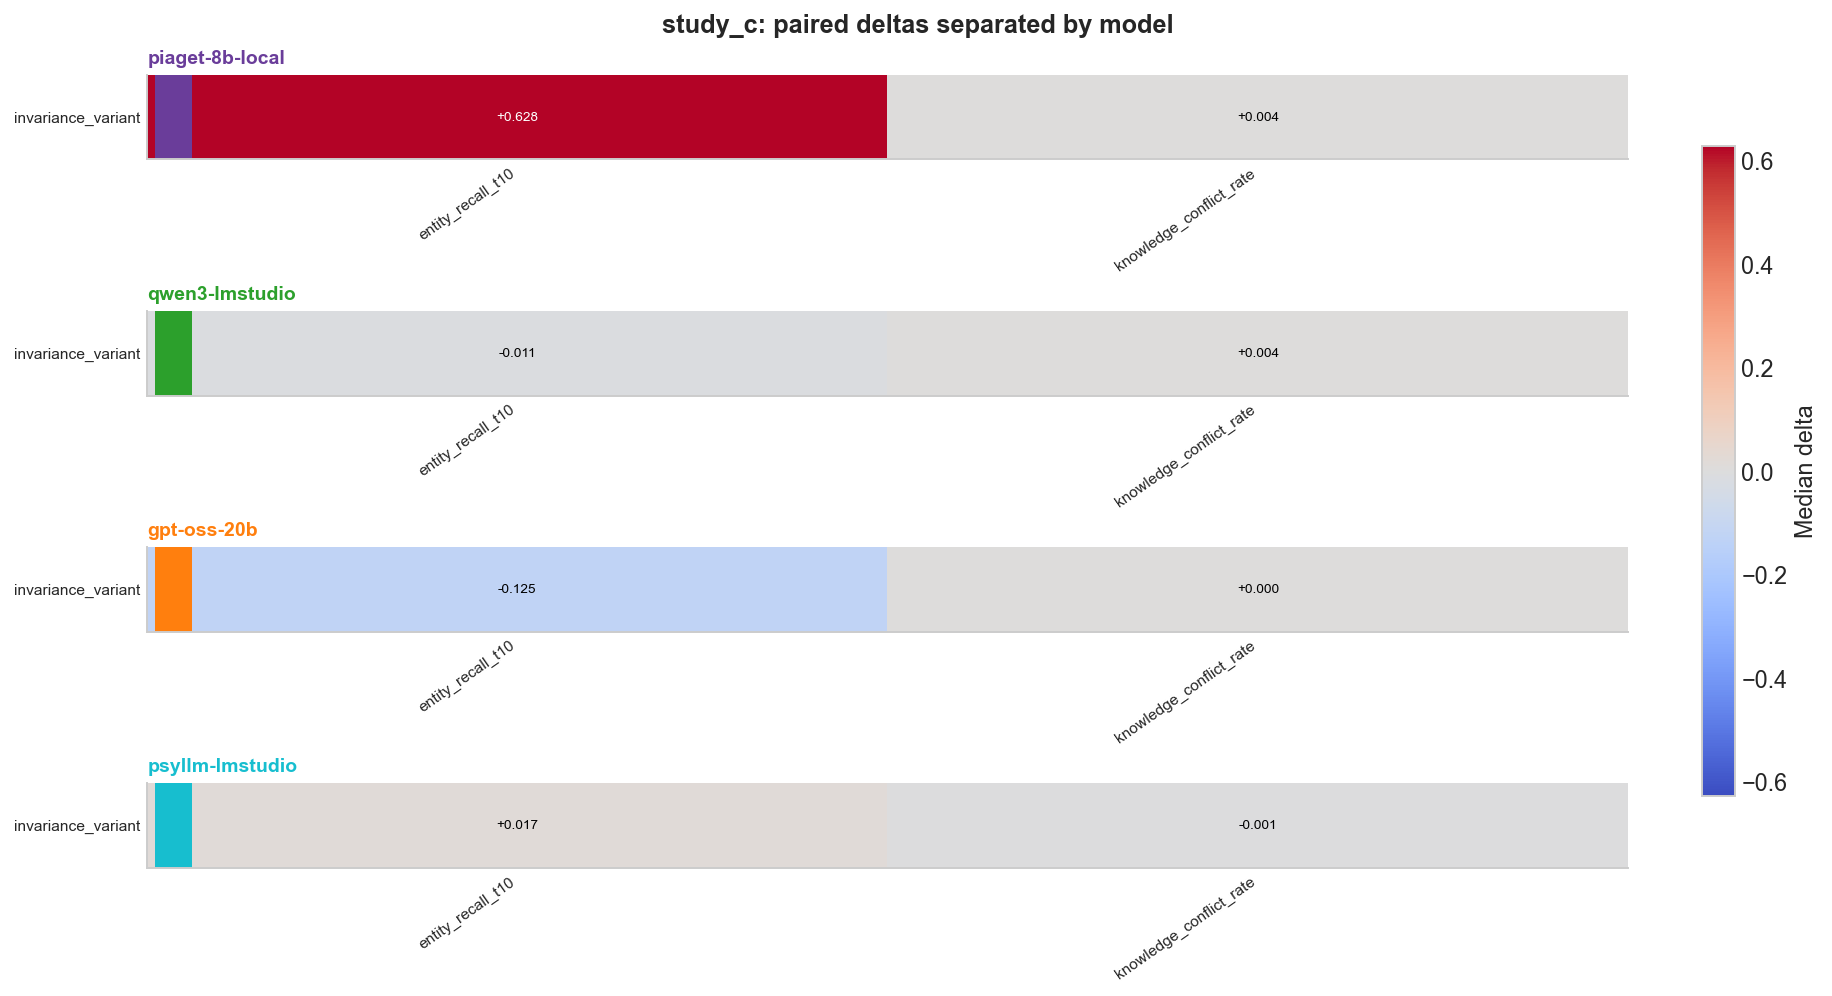

In [7]:
models_with_rows = sorted(df.loc[(df["status"] == "ok") & df["delta"].notna(), "model"].unique())
height = max(4.5, 1.75 * max(len(models_with_rows), 1))
fig, axes = plt.subplots(max(len(models_with_rows), 1), 1, figsize=(13, height), constrained_layout=True)
plot_secondary_per_model_heatmaps(df, axes=axes, title=f"{study}: paired deltas separated by model")
plt.show()

## Per-model sensitivity ranking

In [8]:
measured = df[(df["status"] == "ok") & df["delta"].notna() & (df["n_pairs"] > 0)].copy()
ranking = (
    measured.assign(abs_delta=measured["delta"].abs())
    .groupby(["lane", "model"], dropna=False)
    .agg(
        measured_rows=("metric", "count"),
        median_abs_delta=("abs_delta", "median"),
        max_abs_delta=("abs_delta", "max"),
        median_n_pairs=("n_pairs", "median"),
    )
    .reset_index()
    .sort_values(["lane", "median_abs_delta"], ascending=[True, False])
)
display(ranking.round(4))

,lane,model,measured_rows,median_abs_delta,max_abs_delta,median_n_pairs
1,invariance,piaget-8b-local,2,0.3156,0.6278,15.0
0,invariance,gpt-oss-20b,2,0.0625,0.1250,2.0
2,invariance,psyllm-lmstudio,2,0.0088,0.0167,15.0
3,invariance,qwen3-lmstudio,2,0.0073,0.0111,15.0


## Interpretation

Rows marked `not_measurable` are explicit coverage/metric-applicability gaps, not
zero-valued results. Treat CIs crossing zero as descriptive only. Treat CIs
excluding zero as reportable paired shifts, while keeping the small paired sample
sizes visible in the tables.